# TweetNLP Analysis

Since we found out in our initial analysis that model choice is important in detecting and analyzing hate speech, and both Hine et al. (2017) and our results confirmed that a basic NLTK model may not suffice for this task, we will use the TweetNLP model for our analysis. This model is specifically designed for analyzing tweets and is based on a transformer architecture.

In [ ]:
import pandas as pd

import nltk
from nltk.corpus import stopwords
import re

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np

import seaborn as sns
from sklearn.metrics import confusion_matrix

import spacy
from datetime import datetime

import tweetnlp
from tqdm import tqdm
tqdm.pandas()

# Ignore future warnings
import warnings
warnings.filterwarnings("ignore")

from collections import Counter
import ast
import matplotlib.pyplot as plt


In [ ]:
posts_path = '../Data-Forensics/Data Crawling + Scraping/4chan/output/posts.csv'
threads_path = '../Data-Forensics/Data Crawling + Scraping/4chan/output/threads.csv'

chan4_posts = pd.read_csv(posts_path)
chan4_threads = pd.read_csv(threads_path)

posts_end_path  = '../Data-Forensics/Data Crawling + Scraping/Endchan/output/posts.csv'
threads_end_path = '../Data-Forensics/Data Crawling + Scraping/Endchan/output/threads.csv'

endchan_posts = pd.read_csv(posts_end_path)
endchan_threads = pd.read_csv(threads_end_path)

## Text Pre-processing

For the pre-processing of the text, we will use the same steps as before with the basic NLTK pre-processing.

In [24]:
my_stopwords = nltk.corpus.stopwords.words('english')
word_rooter = nltk.stem.snowball.PorterStemmer(ignore_stopwords=False).stem
my_punctuation = '!"$%&\'()*+,-./:;<=>?[\\]^_`{|}~•@'

In [25]:
# cleaning master function
def clean_thread(thread, bigrams=False):
    if not isinstance(thread, str):  # Handle non-string values
        thread = ''
    thread = thread.lower()  # lower case
    thread = re.sub('[' + my_punctuation + ']+', ' ', thread)  # strip punctuation
    # thread = re.sub('\s+', ' ', thread)  # remove double spacing
    thread = re.sub('([0-9]+)', '', thread)  # remove numbers
    thread_token_list = [word for word in thread.split(' ')
                         if word not in my_stopwords]  # remove stopwords

    # thread_token_list = [word_rooter(word) if '#' not in word else word
    #                      for word in thread_token_list]  # apply word rooter
    if bigrams:
        thread_token_list = thread_token_list + [thread_token_list[i] + '_' + thread_token_list[i + 1]
                                                 for i in range(len(thread_token_list) - 1)]
    thread = ' '.join(thread_token_list)
    return thread

In [26]:
chan4_threads['cleaned'] = chan4_threads['thread_text'].apply(clean_thread)
chan4_threads['cleaned']

0       kill domestic chickens fake pcr test said egg...
1          denmark best country europe tired pretending 
2       kill domestic chickens fake pcr test said egg...
3                                                       
4      racist pagan pro white pagan pro christian pag...
                             ...                        
465     white east asian interbreeding le bad princip...
466    docsits relevantisraeli nuclear program spotte...
467    young white men across world turning fascism n...
468    libs slated get majority  accelerationism answ...
469     baltics   whitebaltics   white baltics   whit...
Name: cleaned, Length: 470, dtype: object

In [27]:
endchan_threads['cleaned'] = endchan_threads['thread_text'].apply(clean_thread)
endchan_threads['cleaned']

0      wrong poor  pathetic  sissy boy whites nowaday...
1        disable heavily damage kike propaganda lies ...
2      like call jerry seinfeld “funnyman” one vermin...
3      natashas  https www scribd com document  natas...
4                         hello soyjak party gemmy board
                             ...                        
130    wtf satanists  planning ww gay olimpics ritual...
131                         many conclusions take stats 
132    extensive research dismantle homosexuality tra...
133    inevitable ways jews try escape persecution po...
134    ww   us nato troops actively fighting russian ...
Name: cleaned, Length: 135, dtype: object

## Topic Modeling

We will use the same topic modeling approach as before, but we will use the TweetNLP model for the analysis. 

In [28]:
topic_model = tweetnlp.load_model('topic_classification')

In [29]:
def get_tweetnlp_topic(text):
    if isinstance(text, str) and text.strip():
        return topic_model.topic(text)['label']
    else:
        return None

In [30]:
def plot_tweetnlp_distribution(df, column='tweetnlp_topic', sort=True, percent=False, figsize=(10, 6)):
    """
    Plots a horizontal bar chart of individual TweetNLP topic labels from a column of lists.

    Parameters:
        df (pd.DataFrame): The DataFrame containing the topic column.
        column (str): Name of the column containing topic lists (as strings or lists).
        sort (bool): Whether to sort the counts before plotting.
        percent (bool): If True, plot percentage distribution instead of raw counts.
        figsize (tuple): Size of the plot figure.
    """
    # Handle stringified lists and explode
    topics_exploded = df[column].dropna().apply(lambda x: ast.literal_eval(str(x))).explode()

    # Count individual topics
    topic_counts = topics_exploded.value_counts()

    # Convert to percentages if requested
    if percent:
        topic_counts = (topic_counts / topic_counts.sum()) * 100

    # Sort if requested
    if sort:
        topic_counts = topic_counts.sort_values()

    # Plot
    plt.figure(figsize=figsize)
    topic_counts.plot(kind='barh')
    plt.title('Distribution of Individual TweetNLP Topics')
    plt.xlabel('Percentage' if percent else 'Count')
    plt.ylabel('Individual Topic')
    plt.tight_layout()
    plt.show()

### Endchan Topic Modeling

In [31]:
endchan_threads['tweetnlp_topic'] = endchan_threads['cleaned'].progress_apply(get_tweetnlp_topic)

100%|██████████| 135/135 [00:16<00:00,  7.96it/s]


In [32]:
endchan_threads['tweetnlp_topic'].value_counts()

tweetnlp_topic
[news_&_social_concern]                                                  91
[news_&_social_concern, science_&_technology]                             8
[business_&_entrepreneurs, news_&_social_concern]                         6
[diaries_&_daily_life]                                                    6
[]                                                                        6
[film_tv_&_video]                                                         2
[learning_&_educational, news_&_social_concern, youth_&_student_life]     2
[fitness_&_health, news_&_social_concern]                                 2
[celebrity_&_pop_culture, film_tv_&_video, news_&_social_concern]         1
[film_tv_&_video, music]                                                  1
[arts_&_culture, other_hobbies]                                           1
[news_&_social_concern, sports]                                           1
[music]                                                                  

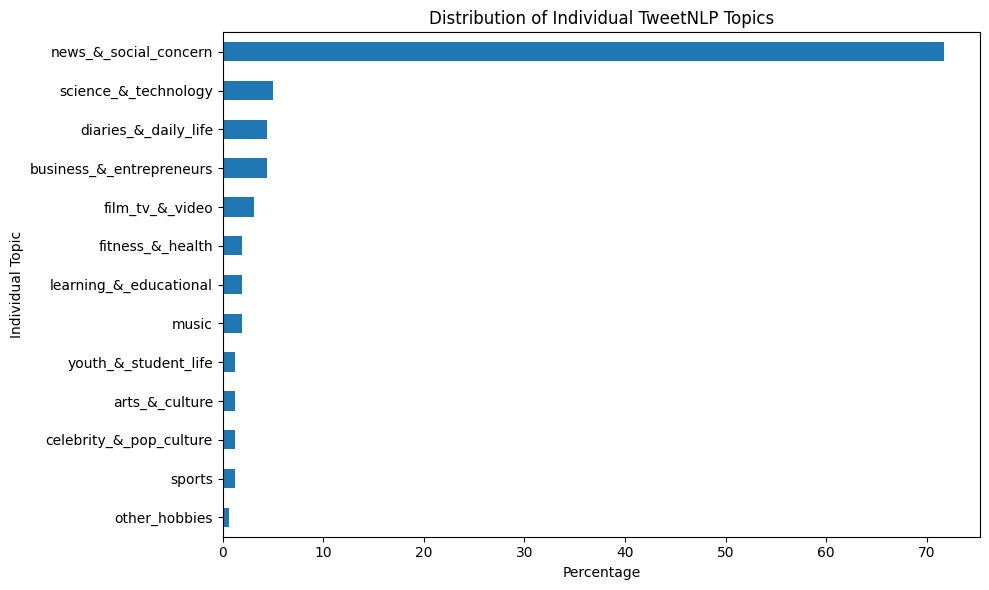

In [33]:
plot_tweetnlp_distribution(endchan_threads, column = 'tweetnlp_topic', percent=True)


In [ ]:
endchan_threads.to_csv('Data/endchan_threads_tweetnlp.csv', index=False)

### 4chan Topic Modeling

In [35]:
chan4_threads['tweetnlp_topic'] = chan4_threads['cleaned'].progress_apply(get_tweetnlp_topic)

100%|██████████| 470/470 [00:32<00:00, 14.36it/s]


In [36]:
chan4_threads['tweetnlp_topic'].value_counts()

tweetnlp_topic
[news_&_social_concern]                                                  237
[diaries_&_daily_life]                                                    57
[news_&_social_concern, science_&_technology]                             29
[]                                                                        22
[business_&_entrepreneurs, news_&_social_concern]                         16
[diaries_&_daily_life, news_&_social_concern]                             16
[film_tv_&_video]                                                          9
[music]                                                                    7
[science_&_technology]                                                     6
[business_&_entrepreneurs]                                                 5
[diaries_&_daily_life, family]                                             5
[sports]                                                                   5
[news_&_social_concern, sports]                              

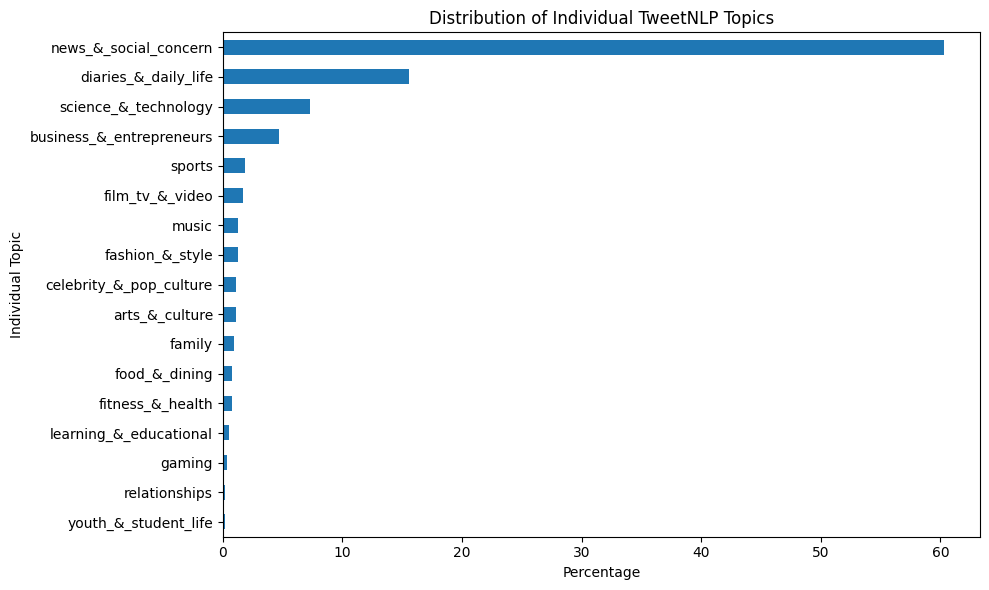

In [37]:
plot_tweetnlp_distribution(chan4_threads, column = 'tweetnlp_topic', percent=True)

In [ ]:
chan4_threads.to_csv('Data/chan4_threads_tweetnlp.csv', index=False)

## Sentiment Analysis

Since TweetNLP also offers an emotion model, a hate speech model, a irony model, and offensive speech model, we can apply these models to our data as well to see whether certain sentiments are more likely to be associated with hate speech, irony, or emotions. 

In [40]:
sentiment_model = tweetnlp.load_model('sentiment')
emotion_model = tweetnlp.load_model('emotion')
hate_model = tweetnlp.load_model('hate')
irony_model = tweetnlp.load_model('irony')
offensive_model = tweetnlp.load_model('offensive')

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [41]:
def analyze_text(text):
    if not isinstance(text, str) or not text.strip():
        return {
            'sentiment_label': None,
            'sentiment_score': None,
            'emotion_label': None,
            'emotion_score': None,
            'hate_label': None,
            'hate_score': None,
            'irony_label': None,
            'irony_score': None,
            'offensive_label': None,
            'offensive_score': None,
        }
    
    # Sentiment
    sentiment = sentiment_model.sentiment(text, return_probability=True)
    sentiment_label = sentiment['label']
    sentiment_score = sentiment['probability'].get(sentiment_label)

    # Emotion
    emotion = emotion_model.emotion(text, return_probability=True)
    emotion_label = emotion['label']
    emotion_score = emotion['probability'].get(emotion_label)

    # Hate
    hate = hate_model.hate(text, return_probability=True)
    hate_label = hate['label']
    hate_score = hate['probability'].get(hate_label)

    # Irony
    irony = irony_model.irony(text, return_probability=True)
    irony_label = irony['label']
    irony_score = irony['probability'].get(irony_label)

    # Offensive language
    offensive = offensive_model.offensive(text, return_probability=True)
    offensive_label = offensive['label']
    offensive_score = offensive['probability'].get(offensive_label)

    return {
        'sentiment_label': sentiment_label,
        'sentiment_score': sentiment_score,
        'emotion_label': emotion_label,
        'emotion_score': emotion_score,
        'hate_label': hate_label,
        'hate_score': hate_score,
        'irony_label': irony_label,
        'irony_score': irony_score,
        'offensive_label': offensive_label,
        'offensive_score': offensive_score,
    }


The function above uses the four models to extract the labels and the scores for each of the models. This can then be applied to the Endchan and 4chan datasets respectively.

In [42]:
endchan_posts['nlp_results'] = endchan_posts['content'].progress_apply(analyze_text)

100%|██████████| 6014/6014 [45:12<00:00,  2.22it/s]  


In [43]:
endchan_results_df = pd.json_normalize(endchan_posts['nlp_results'])
endchan_posts = pd.concat([endchan_posts, endchan_results_df], axis=1)

In [ ]:
endchan_posts.to_csv('Data/endchan_posts_tweetnlp.csv', index=False)

In [44]:
chan4_posts['nlp_results'] = chan4_posts['content'].progress_apply(analyze_text)

100%|██████████| 40459/40459 [3:35:07<00:00,  3.13it/s]  


In [45]:
chan4_results_df = pd.json_normalize(chan4_posts['nlp_results'])
chan4_posts = pd.concat([chan4_posts, chan4_results_df], axis=1)

In [ ]:
chan4_posts.to_csv('Data/chan4_posts_tweetnlp.csv', index=False)

In [48]:
endchan_posts

,subpost_id,content,time,thread_id,vader sentiment,tweetnlp sentiment,nlp_results,sentiment_label,sentiment_score,emotion_label,emotion_score,hate_label,hate_score,irony_label,irony_score,offensive_label,offensive_score
0,91434,>>91417>killed off most of the savage Natives ...,2023-10-28 08:22:00,91417,negative,negative,"{'sentiment_label': 'negative', 'sentiment_sco...",negative,0.829032,anger,0.527929,NOT-HATE,0.920766,non_irony,0.873201,non-offensive,0.634039
1,91435,Netanyahu's not a white boy. Nor is any Yidd. ...,2023-10-28 11:34:00,91417,negative,negative,"{'sentiment_label': 'negative', 'sentiment_sco...",negative,0.862006,anger,0.696499,HATE,0.983856,non_irony,0.641505,offensive,0.835682
2,91448,NaN,2023-10-29 14:19:00,91417,neutral,NaN,"{'sentiment_label': None, 'sentiment_score': N...",None,NaN,None,NaN,None,NaN,None,NaN,None,NaN
3,92023,Idk but it makes me want to pull my hair out. ...,2023-12-26 02:46:00,91417,positive,negative,"{'sentiment_label': 'negative', 'sentiment_sco...",negative,0.903118,anger,0.825111,HATE,0.990403,non_irony,0.945986,offensive,0.794195
4,92024,>>92023,2023-12-26 07:50:00,91417,neutral,neutral,"{'sentiment_label': 'neutral', 'sentiment_scor...",neutral,0.697373,sadness,0.233214,NOT-HATE,0.998304,non_irony,0.747250,non-offensive,0.782101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6009,102358,"Dear Ukraine Dictator Z,Please can we have our...",2025-02-20 17:58:00,93011,positive,negative,"{'sentiment_label': 'negative', 'sentiment_sco...",negative,0.718955,anger,0.727718,NOT-HATE,0.958667,non_irony,0.782467,non-offensive,0.738901
6010,102378,>>102358If you think he does it out of reason ...,2025-02-20 18:45:00,93011,negative,negative,"{'sentiment_label': 'negative', 'sentiment_sco...",negative,0.855993,anger,0.636367,NOT-HATE,0.936469,non_irony,0.761295,offensive,0.550624
6011,102386,">>102358>Dear Zelensky the jew, Donald the jew...",2025-02-20 20:03:00,93011,negative,negative,"{'sentiment_label': 'negative', 'sentiment_sco...",negative,0.915560,anger,0.792991,HATE,0.990899,non_irony,0.617656,offensive,0.685210
6012,102394,>>102378Oh for fuck sake i meant qing dynasty,2025-02-20 21:06:00,93011,negative,negative,"{'sentiment_label': 'negative', 'sentiment_sco...",negative,0.708177,anger,0.654053,HATE,0.994223,non_irony,0.762641,offensive,0.748197


In [49]:
chan4_posts

,subpost_id,content,time,thread_id,vader sentiment,tweetnlp sentiment,nlp_results,sentiment_label,sentiment_score,emotion_label,emotion_score,hate_label,hate_score,irony_label,irony_score,offensive_label,offensive_score
0,p501099183,>>501098958 (OP)I used an anal egg to make me ...,2025-03-21 13:43:02,p501098958,negative,negative,"{'sentiment_label': 'negative', 'sentiment_sco...",negative,0.640528,anger,0.424492,NOT-HATE,0.996788,non_irony,0.836866,offensive,0.772222
1,p501099437,corporate farming was a mistakepicrel is the c...,2025-03-21 13:46:36,p501098958,neutral,negative,"{'sentiment_label': 'negative', 'sentiment_sco...",negative,0.678283,disgust,0.557935,NOT-HATE,0.997350,irony,0.887677,non-offensive,0.665251
2,p501100092,>>501098958 (OP)Almost like the old administra...,2025-03-21 13:55:59,p501098958,negative,negative,"{'sentiment_label': 'negative', 'sentiment_sco...",negative,0.799108,anger,0.670483,NOT-HATE,0.996030,irony,0.522826,offensive,0.838268
3,p501100224,">>501100092Trump started the fake pandemic, st...",2025-03-21 13:57:44,p501098958,negative,negative,"{'sentiment_label': 'negative', 'sentiment_sco...",negative,0.917395,anger,0.720471,NOT-HATE,0.990781,irony,0.691327,offensive,0.618655
4,p501101758,>>501098958 (OP)>what did americans mean by th...,2025-03-21 14:17:04,p501098958,negative,negative,"{'sentiment_label': 'negative', 'sentiment_sco...",negative,0.711611,anger,0.521793,NOT-HATE,0.994084,irony,0.678666,non-offensive,0.669769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40454,p501117648,">>501117485kekprobably will be rejected entry,...",2025-03-21 17:37:59,p501097122,negative,negative,"{'sentiment_label': 'negative', 'sentiment_sco...",negative,0.850562,disgust,0.434586,NOT-HATE,0.997162,non_irony,0.870272,non-offensive,0.867313
40455,p501117745,>>501112191>Not even jokingit really is the on...,2025-03-21 17:39:18,p501097122,positive,negative,"{'sentiment_label': 'negative', 'sentiment_sco...",negative,0.497624,anger,0.725084,HATE,0.937278,non_irony,0.836715,non-offensive,0.803639
40456,p501117750,>>501117648But you are a cuckservative who thi...,2025-03-21 17:39:21,p501097122,positive,neutral,"{'sentiment_label': 'neutral', 'sentiment_scor...",neutral,0.408524,anger,0.579475,HATE,0.992448,non_irony,0.576715,offensive,0.797803
40457,p501117790,">>501117499But those exist.Thing is, that they...",2025-03-21 17:39:48,p501097122,neutral,negative,"{'sentiment_label': 'negative', 'sentiment_sco...",negative,0.533679,anger,0.482008,NOT-HATE,0.934137,non_irony,0.508033,non-offensive,0.688355
